## SAM-Based Mask Prediction and Evaluation

This notebook demonstrates using the Segment Anything Model (SAM) to predict ship masks and evaluate them against ground truth. It loads example images, generates masks with SAM, applies filtering and non-max suppression, and calculates the IoU with the annotated masks.

## Load Ground Truth Masks

We load the segmentation CSV and group RLEs by `ImageId`. This allows quick lookup of all masks for any image.

In [1]:
import pandas as pd

from constants import DATA_PATH

In [2]:
df = pd.read_csv(f"{DATA_PATH}/segmentations.csv")

rle_dict = (
    df.groupby('ImageId')['EncodedPixels']
      .apply(list)
      .to_dict()
)

## Load Example Image

We cherry picked an example image to visualize and test mask generation.

In [3]:
from constants import IMAGE_PATH

In [4]:
EXAMPLE_IMG_ID = "0a286fb15.jpg"
EXAMPLE_IMG_PATH = f"{IMAGE_PATH}/{EXAMPLE_IMG_ID}"

In [5]:
import cv2

from utils import rles_to_masks, show_masks

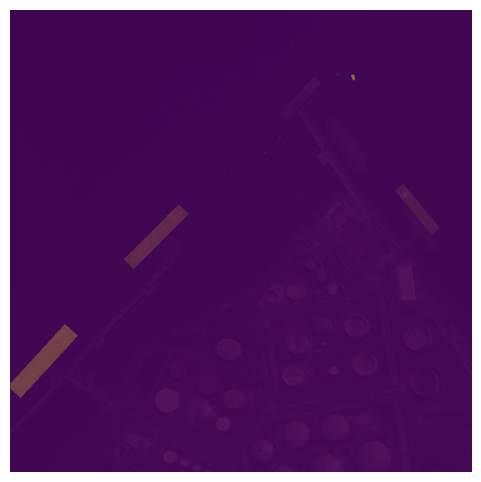

In [6]:
img = cv2.imread(EXAMPLE_IMG_PATH)[:, :, ::-1]
rles = rle_dict[EXAMPLE_IMG_ID]
masks = rles_to_masks(rles, 768, 768)

show_masks(img, masks)

## Setup SAM Model

We load a pretrained SAM model, downloading the checkpoint if necessary. A SamAutomaticMaskGenerator is used with parameters to control prediction quality, number of points, and output mode.

In [7]:
import os
import torch
import urllib.request

from pathlib import Path
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [8]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_PATH = "./checkpoints/sam_vit_h_4b8939.pth"
CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"

Path(os.path.dirname(CHECKPOINT_PATH)).mkdir(parents=True, exist_ok=True)

if not os.path.exists(CHECKPOINT_PATH):
    print("Checkpoint not found. Downloading...")
    urllib.request.urlretrieve(CHECKPOINT_URL, CHECKPOINT_PATH)
    print("Download completed!")


sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH).to(DEVICE)
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    crop_n_layers=0,
    output_mode="binary_mask"
)

## Predict Masks

A helper function generates masks, filters out small or low-quality masks, applies non-max suppression to remove redundant masks, and ensures no overlap between remaining masks. This produces clean, non-overlapping segmentation masks.

In [9]:
import numpy as np

from typing import List, Dict, Any
from utils import filter_mask, non_max_mask_suppression, enforce_no_overlap

In [10]:
def predict_masks(mask_generator: Any, img: np.ndarray) -> List[np.ndarray]:
    """
    Generate and filter masks for an image using a SAM-based mask generator.

    :param mask_generator: Object with a `.generate(img)` method returning a list of mask dictionaries.
    :param img: Input image as a NumPy array (H, W, 3).
    :returns: List of filtered and non-overlapping mask segmentations as Fortran-ordered NumPy arrays.
    """
    masks : List[Dict[str, Any]] = mask_generator.generate(img)
    mask_filter = [filter_mask(m["segmentation"]) for m in masks]
    
    masks = [m for m, keep in zip(masks, mask_filter) if keep]
    
    masks = non_max_mask_suppression(masks, 0.8)
    masks = enforce_no_overlap(masks)
    return [np.asfortranarray(m['segmentation']) for m in masks]

In [11]:
predicted_masks = predict_masks(mask_generator, img)

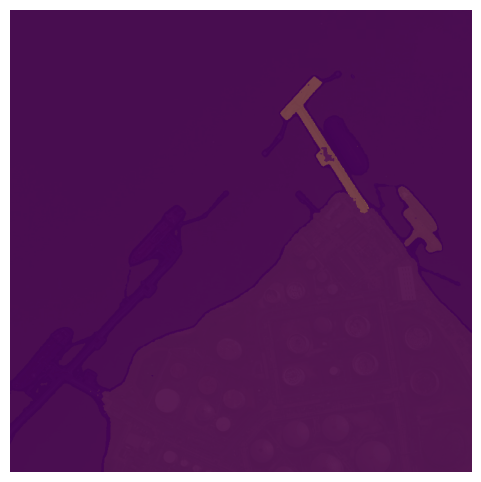

In [12]:
show_masks(img, predicted_masks)

## Evaluate Predictions

Using the ground truth masks, we calculate the IoU for each predicted mask against the annotated masks. This gives a quantitative measure of segmentation quality.

In [13]:
from utils import get_image_iou_mat

In [14]:
iou_matrix = get_image_iou_mat((img, rles), predicted_masks)

float(iou_matrix.mean())

0.02202533930540085